In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import torchvision
from torch import optim, cuda
import random
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline


In [2]:
# connect google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# get datset from mydrive
import zipfile
zip_path = "/content/drive/MyDrive/chestxray.zip"
extract_path = "/content/chestxray"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
# verify that the files were extracted correctly to the target path
import os
os.listdir(extract_path)

['chest_xray']

In [5]:
# defining the directory paths for the training, validation, and testing datasets.
data_dir = "/content/chestxray/chest_xray"
train_dir = data_dir + "/train/"
val_dir = data_dir + "/val/"
test_dir = data_dir + "/test/"

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [7]:
# determine the dataset's distribution, class balance
# Empty lists
class_names = []
image_classes = []
train_counts = []
val_counts = []
test_counts = []
img_heights = []
img_widths = []

# Iterate through each category
for folder in os.listdir(train_dir):
    if not folder.startswith('.'):
        class_names.append(folder)

        # Number of each image
        train_imgs = os.listdir(train_dir + folder)
        val_imgs = os.listdir(val_dir + folder)
        test_imgs = os.listdir(test_dir + folder)

        # Number of datasets
        train_counts.append(len(train_imgs))
        val_counts.append(len(val_imgs))
        test_counts.append(len(test_imgs))

        # Find stats for train images
        for img_name in train_imgs:
            if not img_name.startswith('.'):
                image_classes.append(folder)
                img = Image.open(train_dir + folder + '/' + img_name)
                img_array = np.array(img)

                # Shape
                img_heights.append(img_array.shape[0])
                img_widths.append(img_array.shape[1])

In [8]:
# create dataframe
categories_df = pd.DataFrame({
    "category": class_names,
    "n_train": train_counts,
    "n_valid": val_counts,
    "n_test": test_counts
})

In [9]:
categories_df.sort_values("category")

,category,n_train,n_valid,n_test
0,NORMAL,1341,8,234
1,PNEUMONIA,3875,8,390


Display 6 Random Normal and Pneumonia Images


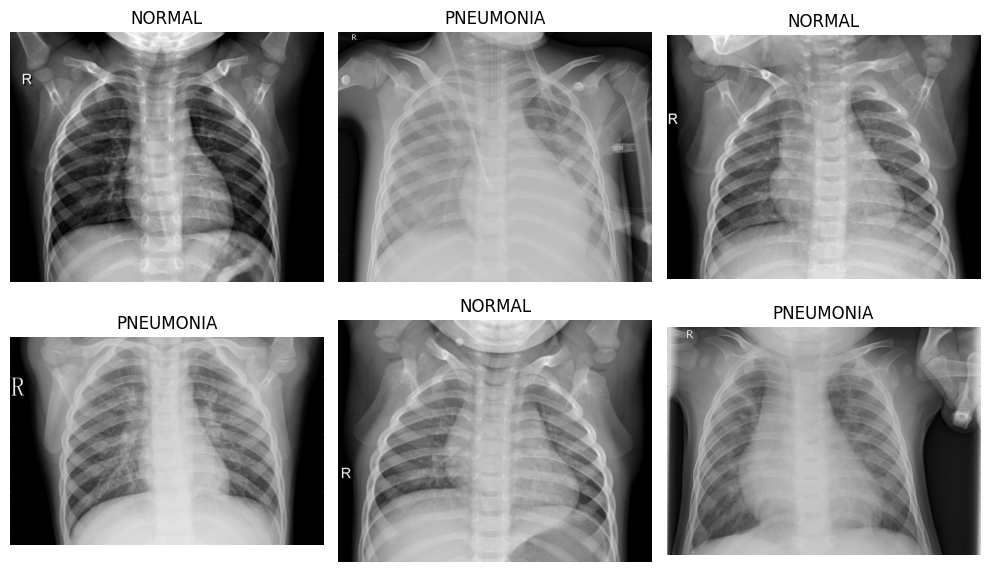

In [10]:
# Display 6 Random Normal and Pneumonia Images
normal_image_paths = []
pneumonia_image_paths = []

# Populate normal_image_paths
normal_dir = os.path.join(train_dir, "NORMAL")
for img_name in os.listdir(normal_dir):
    if not img_name.startswith('.'): # Exclude hidden files like .DS_Store
        normal_image_paths.append(os.path.join(normal_dir, img_name))

# Populate pneumonia_image_paths
pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")
for img_name in os.listdir(pneumonia_dir):
    if not img_name.startswith('.'): # Exclude hidden files
        pneumonia_image_paths.append(os.path.join(pneumonia_dir, img_name))

num_images_per_class = 3
selected_normal_images = random.sample(normal_image_paths, num_images_per_class)
selected_pneumonia_images = random.sample(pneumonia_image_paths, num_images_per_class)

combined_images = selected_normal_images + selected_pneumonia_images
random.shuffle(combined_images)

print('Display 6 Random Normal and Pneumonia Images')

plt.figure(figsize=(10, 6))

for i in range(len(combined_images)):
    plt.subplot(2, 3, i + 1)
    img = plt.imread(combined_images[i])
    plt.imshow(img, cmap='gray')
    label = os.path.basename(os.path.dirname(combined_images[i]))
    plt.title(label, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

(1719, 1972)


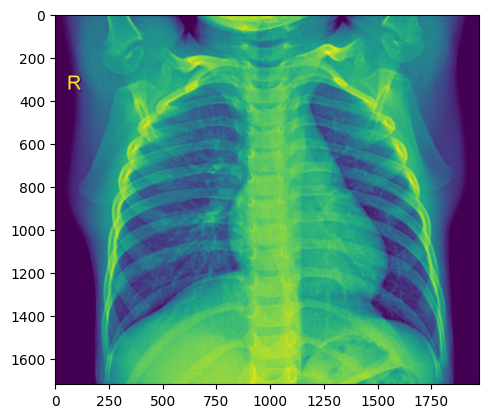

In [11]:
x = Image.open(train_dir + "NORMAL/IM-0166-0001.jpeg")
np.array(x).shape
plt.imshow(x)
print(np.array(x).shape)

(808, 1000)


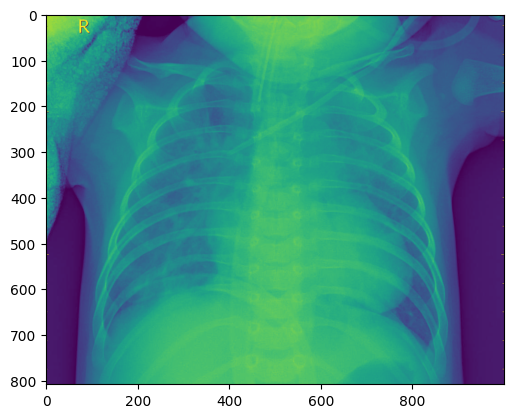

In [12]:
x = Image.open(train_dir + 'PNEUMONIA/person75_bacteria_364.jpeg')
np.array(x).shape
plt.imshow(x)
print(np.array(x).shape)

In [13]:
# Data Augmentation va Preprocessing
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [14]:
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']),
    'val':   datasets.ImageFolder(os.path.join(data_dir, 'val'),   data_transforms['val_test']),
    'test':  datasets.ImageFolder(os.path.join(data_dir, 'test'),  data_transforms['val_test'])
}

In [15]:
BATCH_SIZE = 32
EPOCHS = 12
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
from torch.utils.data import WeightedRandomSampler
class_counts = [1341, 3875]
num_samples = sum(class_counts)
class_weights = [num_samples/c for c in class_counts]
sample_weights = [class_weights[label] for label in image_datasets['train'].targets]

sampler = WeightedRandomSampler(weights=sample_weights,
                                 num_samples=num_samples,
                                 replacement=True)

dataloaders = {}
dataloaders['train'] = DataLoader(
    image_datasets['train'],
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False
)

for x in ['val', 'test']:
    dataloaders[x] = DataLoader(
        image_datasets[x],
        batch_size=BATCH_SIZE,
        shuffle=False
    )

In [17]:
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
print(class_names)


['NORMAL', 'PNEUMONIA']


In [18]:
# Model: DenseNet121
def build_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 2)
    )
    return model.to(DEVICE)

model = build_model()
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.1)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 116MB/s]


In [19]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=12):
    best_acc = 0.0
    train_accs = []
    val_accs = []
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_accs.append(epoch_acc.item())
                train_losses.append(epoch_loss)
            else:
                val_accs.append(epoch_acc.item())
                val_losses.append(epoch_loss)
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), 'optimized_model.pth')

            print(f'{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return train_accs, val_accs, train_losses, val_losses

In [25]:
train_model(model, criterion, optimizer, scheduler, num_epochs=12)

TRAIN Loss: 0.1609 Acc: 0.9411
VAL Loss: 0.1262 Acc: 0.9375
TRAIN Loss: 0.1632 Acc: 0.9350
VAL Loss: 0.1094 Acc: 1.0000
TRAIN Loss: 0.1584 Acc: 0.9394
VAL Loss: 0.1396 Acc: 0.9375
TRAIN Loss: 0.1537 Acc: 0.9423
VAL Loss: 0.1350 Acc: 0.9375
TRAIN Loss: 0.1550 Acc: 0.9402
VAL Loss: 0.1198 Acc: 0.9375
TRAIN Loss: 0.1485 Acc: 0.9452
VAL Loss: 0.1076 Acc: 1.0000
TRAIN Loss: 0.1580 Acc: 0.9406
VAL Loss: 0.1037 Acc: 1.0000
TRAIN Loss: 0.1314 Acc: 0.9521
VAL Loss: 0.1154 Acc: 1.0000
TRAIN Loss: 0.1425 Acc: 0.9450
VAL Loss: 0.1145 Acc: 1.0000
TRAIN Loss: 0.1417 Acc: 0.9486
VAL Loss: 0.1073 Acc: 1.0000
TRAIN Loss: 0.1476 Acc: 0.9469
VAL Loss: 0.1092 Acc: 1.0000
TRAIN Loss: 0.1531 Acc: 0.9452
VAL Loss: 0.1109 Acc: 1.0000


([0.9411426380368099,
  0.9350076687116564,
  0.9394171779141105,
  0.9422929447852761,
  0.9401840490797546,
  0.9451687116564418,
  0.9405674846625767,
  0.9520705521472392,
  0.9449769938650306,
  0.9486196319018405,
  0.9468941717791411,
  0.9451687116564418],
 [0.9375, 1.0, 0.9375, 0.9375, 0.9375, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 [0.1609250410957022,
  0.16321657068936005,
  0.15836030187690917,
  0.15366102608800666,
  0.15501353974265555,
  0.14847127051075543,
  0.15803081766228003,
  0.13143016279109418,
  0.14252313518999543,
  0.1417455291889745,
  0.14764071699300427,
  0.1530772525405774],
 [0.12622404098510742,
  0.10939346253871918,
  0.139644056558609,
  0.1349683701992035,
  0.1197502613067627,
  0.10759279131889343,
  0.10365796089172363,
  0.11543579399585724,
  0.11452947556972504,
  0.10732962936162949,
  0.1091616302728653,
  0.11086177825927734])

In [26]:
# Testing,evaluating the model’s performance
def evaluate_on_test():
    print("The final testing process is beginning...")
    model.load_state_dict(torch.load('optimized_model.pth'))
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

evaluate_on_test()

The final testing process is beginning...

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.80      0.83       234
   PNEUMONIA       0.89      0.93      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624



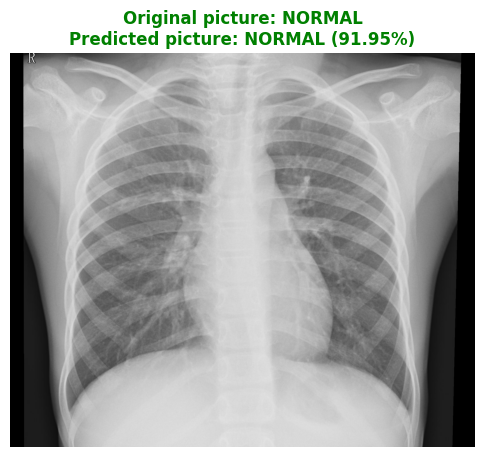

In [36]:
def predict_single_image(model, test_dir, device):
    # 1. Randomly select one image from the test folder
    sub_folders = ['NORMAL', 'PNEUMONIA']
    chosen_folder = random.choice(sub_folders)
    folder_path = os.path.join(test_dir, chosen_folder)

    image_name = random.choice(os.listdir(folder_path))
    image_path = os.path.join(folder_path, image_name)

    # 2. Upload and prepare the image
    img = Image.open(image_path).convert('RGB')
    # We use the val_test transformation used in training
    input_tensor = data_transforms['val_test'](img).unsqueeze(0).to(device)

    # 3. Model prediction
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_label = class_names[predicted_idx.item()]
    actual_label = chosen_folder
    prob_score = confidence.item() * 100

    # 4. Visualize the result
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')

    # If the model finds it correctly, we write it in green, if it finds an error in red
    color = 'green' if predicted_label == actual_label else 'red'

    title_text = f"Original picture: {actual_label}\nPredicted picture: {predicted_label} ({prob_score:.2f}%)"
    plt.title(title_text, color=color, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

model.load_state_dict(torch.load('optimized_model.pth', map_location=DEVICE))
predict_single_image(model, test_dir, DEVICE)

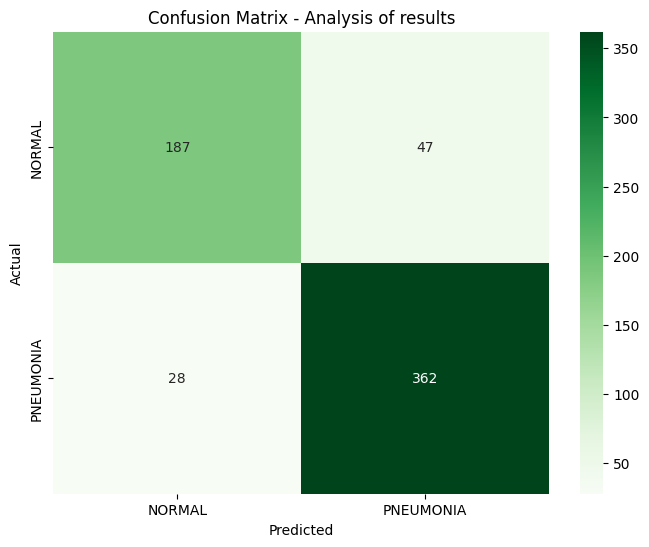

In [37]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Analysis of results')
    plt.show()

plot_confusion_matrix(model, dataloaders['test'], DEVICE)

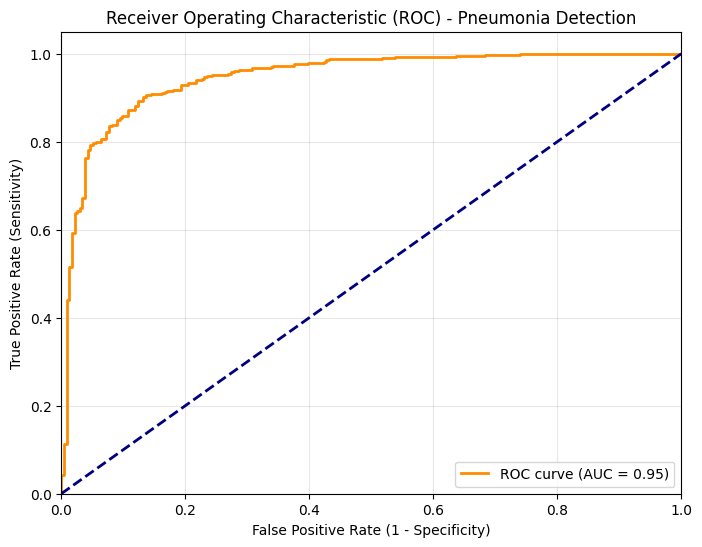

In [38]:
# ROC CURVE
from sklearn.metrics import roc_curve, auc
import torch

def plot_roc_curve(model, test_loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            probs = torch.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())


    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)


    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) - Pneumonia Detection')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()



plot_roc_curve(model, dataloaders['test'], DEVICE)

Original image: PNEUMONIA
Predicted label: PNEUMONIA with 90.25% confidence


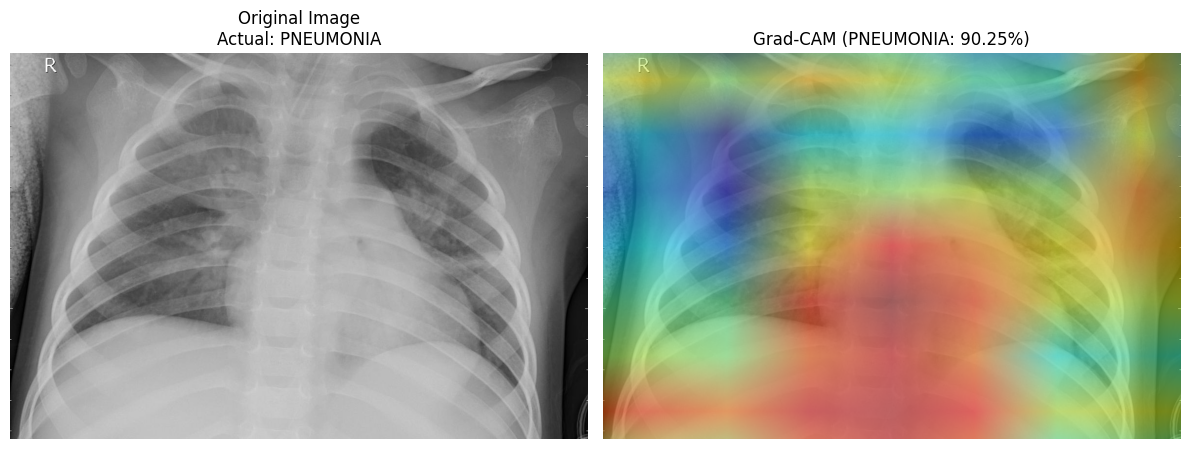

In [82]:
# Grad-CAM
import cv2
from skimage.transform import resize
import torch
import torch.nn.functional as F
import numpy as np

# Define a custom class for Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model.eval()
        self.feature_map = None
        self.gradients = None

        self.target_layer = None
        for name, module in self.model.named_modules():
            if name == target_layer_name:
                self.target_layer = module
                break

        if self.target_layer is None:
            raise ValueError(f"Target layer '{target_layer_name}' not found in the model.")

        # Register a forward hook to save the feature map and ensure it retains gradients
        def hook_fn_forward(module, input, output):
            self.feature_map = output
            self.feature_map.retain_grad()

        self.target_layer.register_forward_hook(hook_fn_forward)

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        self.feature_map = None # Reset feature map for each call

        # Crucial step: Make the input tensor require gradients
        input_tensor.requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward pass with respect to the chosen class
        self.model.zero_grad()
        target_output = output[0, class_idx]
        target_output.backward(retain_graph=True)

        # Get feature map and its gradients
        if self.feature_map is None or self.feature_map.grad is None:
             raise RuntimeError(
                 "Grad-CAM failed: Feature map or its gradients are None. "
                 "Ensure the target layer is correctly identified, and gradients can propagate. "
                 "Check `input_tensor.requires_grad_(True)` and ensure feature extractor layers are unfrozen."
             )

        gradients = self.feature_map.grad.cpu().data.numpy()
        features = self.feature_map.cpu().data.numpy()

        # Global average pooling on gradients
        weights = np.mean(gradients, axis=(2, 3))[0, :]

        # Compute Grad-CAM heatmap
        cam = features[0, :, :, :] * weights[:, np.newaxis, np.newaxis]
        cam = np.maximum(cam, 0) # ReLU operation
        cam = np.mean(cam, axis=0) # Average across channels to get a single 2D heatmap

        # Robust normalization
        cam_min = np.min(cam)
        cam_max = np.max(cam)
        if cam_max == cam_min:
            # If all values are the same, the heatmap is uniform (e.g., all zeros)
            # Set it to zeros to avoid division by zero and represent no activation
            cam = np.zeros(cam.shape, dtype=np.float32)
        else:
            cam = (cam - cam_min) / (cam_max - cam_min)

        # Set requires_grad_ back to False for the input tensor
        input_tensor.requires_grad_(False)

        return cam

def create_cam_image(img, mask, alpha=0.5):
    # mask is now a 2D array (H, W)
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    # Convert PIL Image to numpy array (HWC format)
    img_np = np.array(img)
    # Ensure img_np is float32 for blending
    img_np = np.float32(img_np) / 255

    # Resize heatmap to original image size
    heatmap = resize(heatmap, (img_np.shape[0], img_np.shape[1]), anti_aliasing=True)

    # Blend heatmap with original image
    cam_image = alpha * heatmap + (1 - alpha) * img_np
    cam_image = np.uint8(255 * cam_image)
    return cam_image

# Load the best model weights
model.load_state_dict(torch.load('optimized_model.pth', map_location=DEVICE))

# Select a target layer (e.g., the last convolutional layer in DenseNet's features block)
# Changing to 'features.norm5' which is the final batch normalization layer in DenseNet's features
target_layer_name = 'features.norm5'

# --- Temporarily unfreeze feature extractor for Grad-CAM computation ---
# Store original requires_grad state to restore later
original_feature_requires_grad_states = {}
for name, param in model.named_parameters():
    if name.startswith('features.'): # Only target parameters of the feature extractor
        original_feature_requires_grad_states[name] = param.requires_grad
        param.requires_grad = True # Enable gradients for feature extractor

# Ensure the model is in eval mode for consistent behavior, but allow grad for features
model.eval()

grad_cam_instance = GradCAM(model, target_layer_name)

# --- Predict and visualize for a single random image (similar to predict_single_image) ---

# 1. Randomly select one image from the test folder
sub_folders = ['NORMAL', 'PNEUMONIA']
chosen_folder = random.choice(sub_folders)
folder_path = os.path.join(test_dir, chosen_folder)

image_name = random.choice(os.listdir(folder_path))
image_path = os.path.join(folder_path, image_name)

# 2. Upload and prepare the image
original_img = Image.open(image_path).convert('RGB')
input_tensor = data_transforms['val_test'](original_img).unsqueeze(0).to(DEVICE)

# 3. Model prediction
# This prediction will now correctly use the unfrozen feature layers for Grad-CAM
output = model(input_tensor)
probabilities = torch.nn.functional.softmax(output, dim=1)
confidence, predicted_idx = torch.max(probabilities, 1)

predicted_label = class_names[predicted_idx.item()]
actual_label = chosen_folder
prob_score = confidence.item() * 100

print(f"Original image: {actual_label}")
print(f"Predicted label: {predicted_label} with {prob_score:.2f}% confidence")

# 4. Generate Grad-CAM heatmap
class_idx_for_cam = class_names.index(predicted_label)
heatmap = grad_cam_instance(input_tensor, class_idx=class_idx_for_cam)

# --- Restore original requires_grad state ---
for name, param in model.named_parameters():
    if name.startswith('features.'): # Only target parameters of the feature extractor
        param.requires_grad = original_feature_requires_grad_states[name]

# Restore model to its original eval mode
model.eval()

# 5. Create the Grad-CAM overlaid image
cam_image = create_cam_image(original_img, heatmap)

# 6. Visualize original and Grad-CAM image side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_img)
axes[0].set_title(f'Original Image\nActual: {actual_label}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cam_image)
axes[1].set_title(f'Grad-CAM ({predicted_label}: {prob_score:.2f}%)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()
